## IMPORT

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Dataset Exploration

In [49]:
df = pd.read_csv(r"C:\Users\ngarg\Downloads\train1.csv")
df.head(5)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
df.shape

(42000, 785)

In [51]:
df['label'].nunique()

10

In [52]:
df['label'].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [53]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [55]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


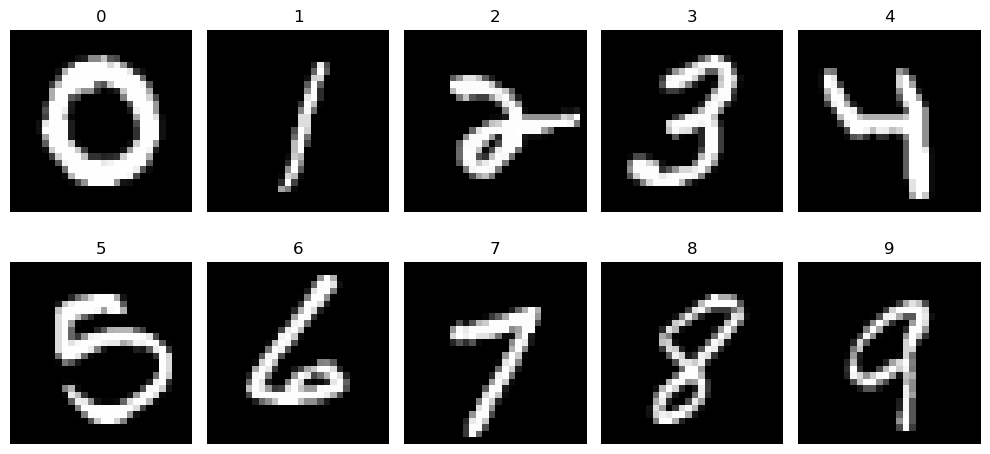

In [56]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

indices = [1, 15, 34, 70, 921, 1081, 998, 961, 1026, 41999]

for ax, idx in zip(axes.ravel(), indices):
    sample = df.iloc[idx]
    label = sample['label']
    image = sample.drop('label').values.reshape(28, 28)

    ax.imshow(image, cmap='grey')
    ax.set_title(f"{label}")
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing

In [57]:
x = df.drop(columns = ['label'])
y = df['label']

In [58]:
x = x.astype(np.float32)
x = x / 255.0

In [59]:
x.shape

(42000, 784)

## 3. Perceptron

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42 ,stratify=y)

In [61]:
X_test = X_test.astype(np.float32)

In [62]:
import joblib
joblib.dump(X_train ,r"C:\Users\ngarg\OneDrive\Desktop\GitHub\MNIST-Digit-Classification\dataset\X_train.pkl")
joblib.dump(X_test ,r"C:\Users\ngarg\OneDrive\Desktop\GitHub\MNIST-Digit-Classification\dataset\X_test.pkl")
joblib.dump(y_train ,r"C:\Users\ngarg\OneDrive\Desktop\GitHub\MNIST-Digit-Classification\dataset\y_train.pkl")
joblib.dump(y_test ,r"C:\Users\ngarg\OneDrive\Desktop\GitHub\MNIST-Digit-Classification\dataset\y_test.pkl")

['C:\\Users\\ngarg\\OneDrive\\Desktop\\GitHub\\MNIST-Digit-Classification\\dataset\\y_test.pkl']

In [63]:
from sklearn.linear_model import Perceptron
modelPer = Perceptron(max_iter=1000 , random_state= 42)
modelPer.fit(X_train , y_train)
y_predict = modelPer.predict(X_test)
accuracy = accuracy_score(y_test , y_predict)
accuracy

0.8675396825396825

In [64]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'alpha': [0.0001, 0.001, 0.01],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'max_iter': [1000, 2000, 3000],
    'eta0': [0.1, 1.0, 10.0]
}

search = RandomizedSearchCV(
    modelPer,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

,estimator,Perceptron(random_state=42)
,param_distributions,"{'alpha': [0.0001, 0.001, ...], 'eta0': [0.1, 1.0, ...], 'max_iter': [1000, 2000, ...], 'penalty': ['l2', 'l1', ...]}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [65]:
print(search.best_params_)
print(search.best_score_)

{'penalty': 'l2', 'max_iter': 1000, 'eta0': 0.1, 'alpha': 0.0001}
0.8743877551020407


In [66]:
best_model = search.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8803174603174603


In [67]:
cm = confusion_matrix(y_test, y_pred)

labels = [0,1,2,3,4,5,6,7,8,9]
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = "Actual"
cm_df.columns.name = "Predicted"
cm_df

Predicted,0,1,2,3,4,5,6,7,8,9
Actual,,,,,,,,,,
0,1184,0,9,8,5,18,6,0,9,1
1,0,1306,40,17,1,17,3,2,19,0
2,2,6,1145,18,27,18,6,9,22,0
3,4,4,46,1135,8,57,4,10,26,11
4,3,4,15,4,1165,8,5,1,0,17
5,17,3,17,55,32,966,9,7,24,9
6,10,3,29,7,18,54,1114,1,5,0
7,8,2,41,5,32,2,2,1172,4,52
8,12,16,57,73,19,86,2,14,926,14


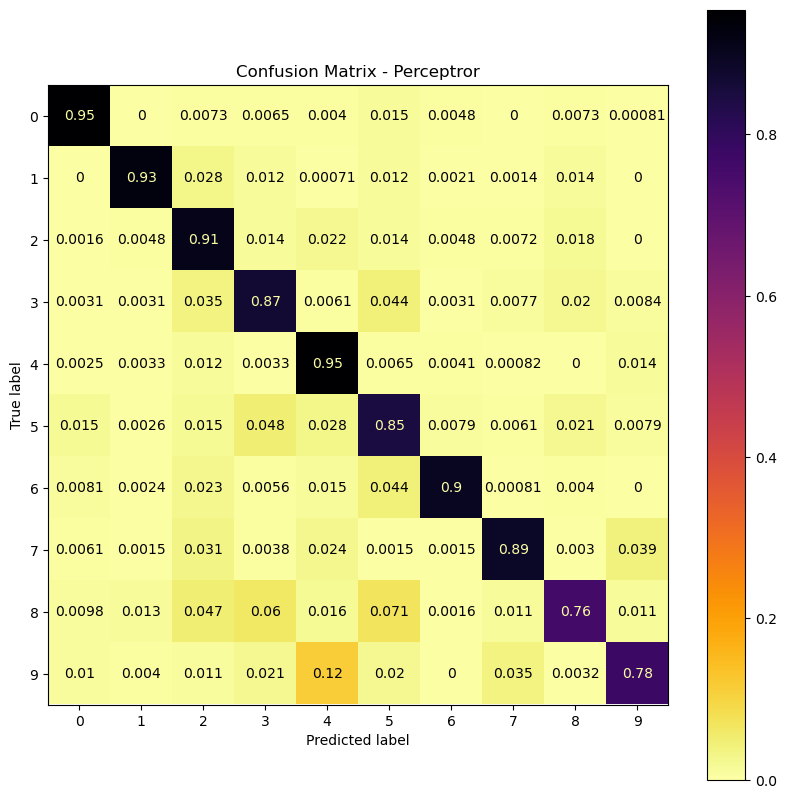

In [68]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10,10))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="inferno_r",
    normalize="true", 
    ax=ax
)

plt.title("Confusion Matrix - Perceptror")
plt.show()

In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1240
           1       0.97      0.93      0.95      1405
           2       0.81      0.91      0.86      1253
           3       0.84      0.87      0.86      1305
           4       0.80      0.95      0.87      1222
           5       0.77      0.85      0.81      1139
           6       0.97      0.90      0.93      1241
           7       0.93      0.89      0.91      1320
           8       0.89      0.76      0.82      1219
           9       0.90      0.78      0.84      1256

    accuracy                           0.88     12600
   macro avg       0.88      0.88      0.88     12600
weighted avg       0.89      0.88      0.88     12600



# Results and Observation (Perceptron Model)

## 1. Model Performance

The Perceptron model was trained using RandomizedSearchCV with cross-validation for hyperparameter tuning. The final model achieved an accuracy of approximately **0.8803 (88.03%)**, while the classification report shows an overall weighted accuracy of approximately **0.88**.

---

## 2. Classification Report Analysis

The classification report shows variation in performance across different digit classes. Digits such as **0, 1, and 6** achieved high precision and recall values (above 0.90), indicating strong classification performance.

However, digits such as **3, 5, 8, and 9** show comparatively lower performance. In particular, digit **9 has the lowest recall (0.76)**, indicating that many samples of digit 9 are misclassified as other digits.

Overall, the macro average F1-score is approximately **0.88**, while the weighted average F1-score is approximately **0.88**, indicating moderate but consistent performance across the dataset.

---

## 3. Confusion Matrix Analysis

The confusion matrix confirms that the model performs well on simpler digits but struggles with visually similar digits.

- Digit **0 and 4** are mostly correctly classified.
- Digit **8 is frequently misclassified**, especially as 2, 3, 5, and 9.
- Digit **5 and 9** also show noticeable confusion with other similar digits.

This indicates that certain handwritten digit shapes overlap in feature space, making them difficult for a linear classifier like Perceptron to distinguish.

---

## 4. Final Observation

The Perceptron model achieves moderate performance on the MNIST dataset. However, it struggles with complex and non-linearly separable digit patterns due to its linear decision boundary limitation.

While hyperparameter tuning improves stability, it does not significantly overcome the inherent limitations of the model.

---

## 5. Code Output Summary

- Best Model Accuracy (CV tuned): **0.88**
- Test Accuracy: **0.88**
- Weighted F1-score: **0.88**

In [70]:
import joblib
joblib.dump(best_model ,r"C:\Users\ngarg\OneDrive\Desktop\GitHub\MNIST-Digit-Classification\Perceptron\perceptron_rs.pkl")

['C:\\Users\\ngarg\\OneDrive\\Desktop\\GitHub\\MNIST-Digit-Classification\\Perceptron\\perceptron_rs.pkl']